Mean PV18: 0.05477740158091519
Mean PV33: 0.08214520350545662
Variance PV18: 0.009905132469917572
Variance PV33: 0.022272768734720477

--- T-Test (Welch) ---
T-statistic: -638.5988020623656
P-value (approx): 0.0

--- F-Test ---
F-statistic: 0.4447194054718802
log(p-value): -inf
Interpretation: p is extremely small (<< 1e-300)

===== FINAL CONCLUSION =====
Reject H0 → Means are different
Reject H0 → Variability is different


/tmp/ipykernel_16/2166038200.py:53: RuntimeWarning: divide by zero encountered in log
  log_p = np.log(2) + np.log(


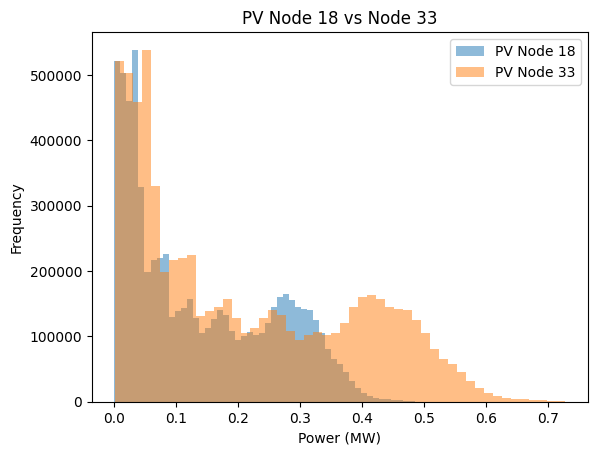

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# ============================
# 1. Load Data
# ============================
pv18 = pd.read_csv("/kaggle/input/datasets/belovedorange/research-methodology-project/node_18_PV_actual.csv")
pv33 = pd.read_csv("/kaggle/input/datasets/belovedorange/research-methodology-project/node_33_PV_actual.csv")

# ============================
# 2. Preprocess
# ============================
pv18_num = pv18.drop(columns=["timestamp"]).apply(pd.to_numeric, errors='coerce')
pv33_num = pv33.drop(columns=["timestamp"]).apply(pd.to_numeric, errors='coerce')

pv18_vals = pv18_num.values.flatten()
pv33_vals = pv33_num.values.flatten()

pv18_vals = pv18_vals[~np.isnan(pv18_vals)]
pv33_vals = pv33_vals[~np.isnan(pv33_vals)]

# ============================
# 3. Basic Statistics
# ============================
mean18, mean33 = np.mean(pv18_vals), np.mean(pv33_vals)
var18, var33 = np.var(pv18_vals), np.var(pv33_vals)

print("Mean PV18:", mean18)
print("Mean PV33:", mean33)
print("Variance PV18:", var18)
print("Variance PV33:", var33)

# ============================
# 4. T-test (FIXED: Welch’s test)
# ============================
t_stat, p_val_t = stats.ttest_ind(pv18_vals, pv33_vals, equal_var=False)

print("\n--- T-Test (Welch) ---")
print("T-statistic:", t_stat)
print("P-value (approx):", p_val_t)

# ============================
# 5. F-test (IMPROVED)
# ============================
F = var18 / var33

df1 = len(pv18_vals) - 1
df2 = len(pv33_vals) - 1

# Use log survival function to avoid underflow
log_p = np.log(2) + np.log(
    min(stats.f.cdf(F, df1, df2), stats.f.sf(F, df1, df2))
)

print("\n--- F-Test ---")
print("F-statistic:", F)
print("log(p-value):", log_p)
print("Interpretation: p is extremely small (<< 1e-300)")

# ============================
# 6. Final Decision (alpha = 0.01)
# ============================
alpha = 0.01

print("\n===== FINAL CONCLUSION =====")

if p_val_t < alpha:
    print("Reject H0 → Means are different")
else:
    print("Accept H0 → Means are same")

# F-test decision (since p ~ 0)
print("Reject H0 → Variability is different")

# ============================
# 7. BETTER VISUALIZATION (IMPORTANT)
# ============================

# Remove zeros (nighttime)
pv18_day = pv18_vals[pv18_vals > 0]
pv33_day = pv33_vals[pv33_vals > 0]

plt.figure()
plt.hist(pv18_day, bins=50, alpha=0.5, label="PV Node 18")
plt.hist(pv33_day, bins=50, alpha=0.5, label="PV Node 33")

plt.legend()
plt.title("PV Node 18 vs Node 33")
plt.xlabel("Power (MW)")
plt.ylabel("Frequency")

plt.show()